# Notebook 04 — TF-IDF + Classical ML (Section 5)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
import pickle

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

OUTPUTS_DIR = Path("outputs")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

print("Libraries loaded.")

Libraries loaded.


## 1. Load Train/Test Data

In [2]:
train_df = pd.read_csv(OUTPUTS_DIR / 'train.csv')
test_df = pd.read_csv(OUTPUTS_DIR / 'test.csv')

print(f"Train: {len(train_df)} | Test: {len(test_df)}")

# Define 3 tasks
TASKS = {
    'star_rating': {'col': 'star_rating', 'type': 'classification'},
    'sentiment':   {'col': 'sentiment', 'type': 'classification'},
    'category':    {'col': 'category', 'type': 'classification'},
}

# Drop rows with missing labels
for task, info in TASKS.items():
    col = info['col']
    train_df = train_df[train_df[col].notna()]
    test_df = test_df[test_df[col].notna()]

print("Cleaned. Shapes:", train_df.shape, test_df.shape)

Train: 19282 | Test: 4821
Cleaned. Shapes: (19282, 14) (4821, 14)


## 2. Define Models

In [3]:
CLASSIFIERS = {
    'LogisticRegression': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'LinearSVC': LinearSVC(max_iter=2000, C=1.0, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

TFIDF = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2
)

## 3. Train and Evaluate All Models × All Tasks

In [4]:
results = {}

for task_name, task_info in TASKS.items():
    col = task_info['col']
    print(f"\n{'='*60}")
    print(f"Task: {task_name}")
    print(f"{'='*60}")
    
    X_train = train_df['text'].fillna('')
    X_test = test_df['text'].fillna('')
    y_train = train_df[col].astype(str)
    y_test = test_df[col].astype(str)
    
    # Fit TF-IDF on train
    tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1,2), sublinear_tf=True, min_df=2)
    X_train_tfidf = tfidf.fit_transform(X_train)
    X_test_tfidf = tfidf.transform(X_test)
    
    # Save TF-IDF
    with open(MODELS_DIR / f'tfidf_{task_name}.pkl', 'wb') as f:
        pickle.dump(tfidf, f)
    
    results[task_name] = {}
    
    for clf_name, clf in CLASSIFIERS.items():
        print(f"\n--- {clf_name} ---")
        clf.fit(X_train_tfidf, y_train)
        y_pred = clf.predict(X_test_tfidf)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average='macro', zero_division=0)
        print(f"Accuracy: {acc:.4f} | F1-macro: {f1:.4f}")
        print(classification_report(y_test, y_pred, zero_division=0))
        
        results[task_name][clf_name] = {'accuracy': acc, 'f1_macro': f1}
        
        # Save best model per task (LogisticRegression)
        if clf_name == 'LogisticRegression':
            with open(MODELS_DIR / f'tfidf_logreg_{task_name}.pkl', 'wb') as f:
                pickle.dump(clf, f)


Task: star_rating

--- LogisticRegression ---
Accuracy: 0.5296 | F1-macro: 0.4350
              precision    recall  f1-score   support

           1       0.59      0.89      0.71      1462
           2       0.32      0.12      0.18       736
           3       0.35      0.17      0.23       676
           4       0.47      0.48      0.48      1012
           5       0.57      0.60      0.58       935

    accuracy                           0.53      4821
   macro avg       0.46      0.45      0.43      4821
weighted avg       0.49      0.53      0.49      4821


--- LinearSVC ---
Accuracy: 0.5061 | F1-macro: 0.4388
              precision    recall  f1-score   support

           1       0.62      0.80      0.70      1462
           2       0.34      0.23      0.28       736
           3       0.30      0.19      0.23       676
           4       0.44      0.44      0.44      1012
           5       0.53      0.57      0.55       935

    accuracy                           0.51    

## 4. Confusion Matrices

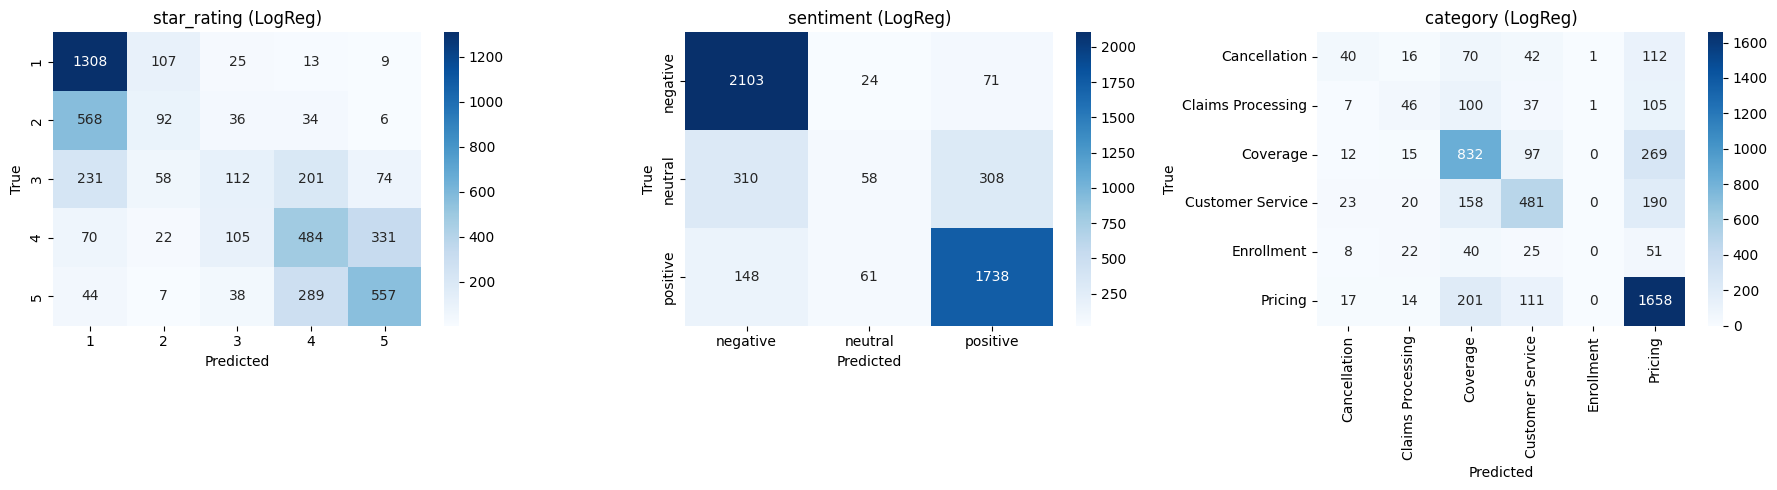

Saved confusion_matrices_tfidf.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (task_name, task_info) in zip(axes, TASKS.items()):
    col = task_info['col']
    
    # Load saved TF-IDF
    with open(MODELS_DIR / f'tfidf_{task_name}.pkl', 'rb') as f:
        tfidf = pickle.load(f)
    with open(MODELS_DIR / f'tfidf_logreg_{task_name}.pkl', 'rb') as f:
        clf = pickle.load(f)
    
    X_test = test_df['text'].fillna('')
    y_test = test_df[col].astype(str)
    
    X_test_tfidf = tfidf.transform(X_test)
    y_pred = clf.predict(X_test_tfidf)
    
    labels = sorted(y_test.unique())
    cm = confusion_matrix(y_test, y_pred, labels=labels)
    
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                xticklabels=labels, yticklabels=labels, cmap='Blues')
    ax.set_title(f'{task_name} (LogReg)')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.tight_layout()
plt.savefig(OUTPUTS_DIR / 'confusion_matrices_tfidf.png', dpi=100)
plt.show()
print("Saved confusion_matrices_tfidf.png")

## 5. Results Summary

In [6]:
rows = []
for task, clf_results in results.items():
    for clf_name, metrics in clf_results.items():
        rows.append({
            'Task': task,
            'Model': clf_name,
            'Accuracy': round(metrics['accuracy'], 4),
            'F1-macro': round(metrics['f1_macro'], 4),
        })

results_df = pd.DataFrame(rows)
results_df = results_df.sort_values(['Task', 'F1-macro'], ascending=[True, False])
print(results_df.to_string(index=False))
results_df.to_csv(OUTPUTS_DIR / 'results_tfidf_classical.csv', index=False)
print("\nSaved results to outputs/results_tfidf_classical.csv")

       Task              Model  Accuracy  F1-macro
   category          LinearSVC    0.6065    0.4061
   category LogisticRegression    0.6341    0.3980
   category       RandomForest    0.6127    0.3401
  sentiment          LinearSVC    0.7949    0.6358
  sentiment LogisticRegression    0.8088    0.6269
  sentiment       RandomForest    0.7888    0.5649
star_rating          LinearSVC    0.5061    0.4388
star_rating LogisticRegression    0.5296    0.4350
star_rating       RandomForest    0.5043    0.3441

Saved results to outputs/results_tfidf_classical.csv


## Summary
- TF-IDF (unigrams+bigrams, 20K features) + 3 classifiers
- 3 tasks: star_rating (5-class), sentiment (3-class), category (6-class)
- Best results saved to `models/`
- Results CSV saved for final comparison notebook